# Volume-spilled sensitivity analysis with common-seed replicates

This notebook evaluates the final-time HECO convex-hull footprint over **500–2000 m³**. It uses:

- `heco.run(...)` for every simulation;
- `heco.output_points_toconvexhull_polygons(...)` for the multitemporal convex hulls;
- `polygons_score.compute_metrics(...)` for SRA, Jaccard, Dice, and Centroid Index;
- the same replicate seed for the 1000 m³ reference and every volume in that replicate (common-seed design);
- repeated simulations per volume;
- a separate test-0 self-comparison at 1000 m³ used **only as a sanity check**, never as a sensitivity observation.

> **Volume representation.** Native HECO particle trajectories do not use `volume_spilled_m3` directly. To make volume observable to a position-only convex hull, this notebook keeps the represented volume per released particle constant and changes the particle count with spill volume. Particle counts are multiples of the six release steps so HECO does not truncate them. This measures a **particle-sampling/convex-hull proxy**, not physical mass-dependent spreading, slick thickness, weathering, or concentration.

The computational cells below are intentionally unexecuted. Review the settings before running the simulation cell.

In [1]:
from contextlib import redirect_stderr, redirect_stdout
from copy import deepcopy
from pathlib import Path
import time

ANALYSIS_DIR = Path.cwd().resolve()
required_local_files = [ANALYSIS_DIR / "heco.py", ANALYSIS_DIR / "polygons_score.py"]
missing_local_files = [str(path) for path in required_local_files if not path.exists()]
if missing_local_files:
    raise FileNotFoundError(
        "Start the kernel in the sensitivity-analysis folder. Missing local modules: "
        + ", ".join(missing_local_files)
    )

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy import stats
import yaml

import heco
import polygons_score

for local_module in (heco, polygons_score):
    if Path(local_module.__file__).resolve().parent != ANALYSIS_DIR:
        raise ImportError(
            f"Imported {local_module.__name__} from {local_module.__file__}, "
            f"not from {ANALYSIS_DIR}."
        )

## Experiment settings

The design uses 48–192 released particles in multiples of six, corresponding to 500–2000 m³ at a constant 1000/96 m³ per particle. This gives 25 volume levels and includes 1000 m³ exactly. The benchmark is removed from the sensitivity runs and represented only by the test-0 self-check. Five replicate seeds are provided by default, and each seed is reused across all volumes.

In [2]:
DATASET_PATH = ANALYSIS_DIR / "HECO_TEST.nc"
OUTPUT_DIR = ANALYSIS_DIR / "sa_2_5_common_seed_replicates"

BENCHMARK_VOLUME_M3 = 1000.0
VOLUME_MIN_M3 = 500.0
VOLUME_MAX_M3 = 2000.0
SPILL_RELEASE_DURATION_H = 6.0
SIM_TIMESTEP_S = 3600.0
RELEASE_STEPS = int(SPILL_RELEASE_DURATION_H * 3600 / SIM_TIMESTEP_S)
BENCHMARK_EFFECTIVE_PARTICLES = 96  # divisible by six; original 100 is truncated to 96 by HECO
VOLUME_PER_PARTICLE_M3 = BENCHMARK_VOLUME_M3 / BENCHMARK_EFFECTIVE_PARTICLES
PARTICLES_PER_RELEASE_MIN = 8
PARTICLES_PER_RELEASE_MAX = 32
N_REPLICATES = 5
MASTER_SEED = 20260803
PROJECTED_CRS = "EPSG:32632"
INTERPOLATED_VELOCITY = False
SAVE_POINT_CSV = False

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"{DATASET_PATH} was not found. Start Jupyter in the sensitivity-analysis folder."
    )
if N_REPLICATES < 2:
    raise ValueError("N_REPLICATES must be at least 2 to estimate uncertainty.")

particles_per_release = np.arange(
    PARTICLES_PER_RELEASE_MIN,
    PARTICLES_PER_RELEASE_MAX + 1,
    dtype=int,
)
particle_count_grid = particles_per_release * RELEASE_STEPS
volume_grid = particle_count_grid.astype(float) * VOLUME_PER_PARTICLE_M3
if not np.isclose(volume_grid[[0, -1]], [VOLUME_MIN_M3, VOLUME_MAX_M3]).all():
    raise ValueError("Particle design does not match the requested 500–2000 m³ range.")
benchmark_matches = np.isclose(volume_grid, BENCHMARK_VOLUME_M3, rtol=0.0, atol=1e-9)
if benchmark_matches.sum() != 1:
    raise ValueError("The configured volume grid must contain 1000 m³ exactly once.")
test_design = pd.DataFrame({
    "volume_spilled_m3": volume_grid[~benchmark_matches],
    "sim_particles": particle_count_grid[~benchmark_matches],
})

seed_sequences = np.random.SeedSequence(MASTER_SEED).spawn(N_REPLICATES)
replicate_seeds = [
    int(sequence.generate_state(1, dtype=np.uint32)[0])
    for sequence in seed_sequences
]

base_config = {
    "input": {
        "dataset_file_name": str(DATASET_PATH.resolve()),
        "lat0": 40.5,
        "lon0": 10.5,
        "sim_diffusion_coeff": 10.0,
        "sim_duration_h": 72.0,
        "sim_particles": float(BENCHMARK_EFFECTIVE_PARTICLES),
        "sim_timedelta_s": SIM_TIMESTEP_S,
        "spill_release_duration_h": SPILL_RELEASE_DURATION_H,
        "time0": "2025-03-08 00:00:00",
        "volume_spilled_m3": BENCHMARK_VOLUME_M3,
    }
}

experiment_settings = {
    "benchmark_volume_m3": BENCHMARK_VOLUME_M3,
    "volume_min_m3": VOLUME_MIN_M3,
    "volume_max_m3": VOLUME_MAX_M3,
    "n_volume_levels_including_benchmark": int(len(volume_grid)),
    "n_sensitivity_volumes": int(len(test_design)),
    "release_steps": RELEASE_STEPS,
    "benchmark_effective_particles": BENCHMARK_EFFECTIVE_PARTICLES,
    "volume_per_particle_m3": VOLUME_PER_PARTICLE_M3,
    "particle_count_min": int(particle_count_grid.min()),
    "particle_count_max": int(particle_count_grid.max()),
    "n_replicates": N_REPLICATES,
    "master_seed": MASTER_SEED,
    "replicate_seeds": replicate_seeds,
    "projected_crs": PROJECTED_CRS,
    "interpolated_velocity": INTERPOLATED_VELOCITY,
}

print(experiment_settings)

{'benchmark_volume_m3': 1000.0, 'volume_min_m3': 500.0, 'volume_max_m3': 2000.0, 'n_volume_levels_including_benchmark': 25, 'n_sensitivity_volumes': 24, 'release_steps': 6, 'benchmark_effective_particles': 96, 'volume_per_particle_m3': 10.416666666666666, 'particle_count_min': 48, 'particle_count_max': 192, 'n_replicates': 5, 'master_seed': 20260803, 'replicate_seeds': [367761876, 1767922150, 1023912954, 1190329654, 485754607], 'projected_crs': 'EPSG:32632', 'interpolated_velocity': False}


## Simulation and polygon helpers

Each run writes its YAML configuration, HECO log, and convex-hull GeoJSON into a replicate-specific directory. Point CSVs are optional because they can be large. The HECO convex-hull helper is used directly, and polygon timestamps are retained explicitly for robust matching.

In [3]:
def volume_tag(volume_m3: float) -> str:
    """Return a filesystem-safe, sortable volume label."""
    return f"{volume_m3:09.3f}".replace(".", "p")


def output_to_convex_hulls(output: pd.DataFrame) -> gpd.GeoDataFrame:
    """Convert a HECO point table to timestamped convex hulls via HECO."""
    required = {"time", "lat", "lon"}
    missing = required.difference(output.columns)
    if missing:
        raise ValueError(f"HECO output is missing columns: {sorted(missing)}")
    if output.empty:
        raise ValueError("HECO returned an empty point table.")

    points = gpd.GeoDataFrame(
        output.copy(),
        geometry=gpd.points_from_xy(output["lon"], output["lat"]),
        crs="EPSG:4326",
    )
    hull_series = heco.output_points_toconvexhull_polygons(points.copy())
    hulls = gpd.GeoDataFrame(
        {"time": [str(value) for value in hull_series.index]},
        geometry=list(hull_series.values),
        crs=points.crs,
    )
    hulls["_sort_time"] = pd.to_datetime(hulls["time"])
    hulls = hulls.sort_values("_sort_time").drop(columns="_sort_time").reset_index(drop=True)
    return hulls


def run_case(config: dict, seed: int, case_dir: Path, stem: str) -> dict:
    """Run one seeded HECO case and persist the artifacts needed for scoring."""
    case_dir.mkdir(parents=True, exist_ok=True)
    config_path = case_dir / f"{stem}.yaml"
    log_path = case_dir / f"{stem}.log"
    hull_path = case_dir / f"{stem}_convex_hulls.geojson"
    point_csv_path = case_dir / f"{stem}_points.csv"

    with config_path.open("w", encoding="utf-8") as stream:
        yaml.safe_dump(config, stream, sort_keys=False)

    with log_path.open("w", encoding="utf-8") as log_stream:
        with redirect_stdout(log_stream), redirect_stderr(log_stream):
            output = heco.run(
                str(config_path),
                seed=int(seed),
                interpolated=INTERPOLATED_VELOCITY,
            )

    if SAVE_POINT_CSV:
        output.to_csv(point_csv_path, index=False)

    hulls = output_to_convex_hulls(output)
    hulls.to_file(hull_path, driver="GeoJSON")

    return {
        "config_path": config_path,
        "log_path": log_path,
        "hull_path": hull_path,
        "point_csv_path": point_csv_path if SAVE_POINT_CSV else None,
    }

## Polygon scoring

Scores are calculated at the latest timestamp after verifying that reference and tested hull files contain identical timestamp sets. Matching is performed by timestamp rather than assuming that GeoJSON row order is identical. `polygons_score` returns Jaccard as `J`; it is renamed to `Jaccard` in the result table.

In [4]:
def read_timestamped_hulls(path: Path) -> gpd.GeoDataFrame:
    hulls = gpd.read_file(path)
    if "time" not in hulls.columns:
        raise ValueError(f"Hull file has no 'time' field: {path}")
    hulls = hulls.reset_index(drop=True)
    hulls["_time"] = pd.to_datetime(hulls["time"])
    if hulls["_time"].duplicated().any():
        raise ValueError(f"Hull file contains duplicate timestamps: {path}")
    return hulls


def score_latest_common_hull(reference_path: Path, simulation_path: Path) -> dict:
    """Score the latest common timestamp with polygons_score.compute_metrics."""
    reference = read_timestamped_hulls(reference_path)
    simulation = read_timestamped_hulls(simulation_path)

    reference_times = set(reference["_time"])
    simulation_times = set(simulation["_time"])
    if reference_times != simulation_times:
        raise ValueError(
            "Reference and simulation hull files do not contain identical timestamp sets."
        )
    if not reference_times:
        raise ValueError("Reference and simulation hull files contain no timestamps.")
    latest_time = max(reference_times)

    reference_idx = int(reference.index[reference["_time"].eq(latest_time)][0])
    simulation_idx = int(simulation.index[simulation["_time"].eq(latest_time)][0])
    for label, hulls, feature_idx in (
        ("reference", reference, reference_idx),
        ("simulation", simulation, simulation_idx),
    ):
        geometry = hulls.geometry.iloc[feature_idx]
        if (
            geometry is None
            or geometry.geom_type not in {"Polygon", "MultiPolygon"}
            or geometry.is_empty
            or geometry.area <= 0
            or not geometry.is_valid
        ):
            raise ValueError(f"Latest {label} hull is empty, invalid, or has zero area.")
    metric = polygons_score.compute_metrics(
        reference_path,
        simulation_path,
        obs_idx=reference_idx,
        sim_idx=simulation_idx,
        projected_crs=PROJECTED_CRS,
    )

    return {
        "sim_time": latest_time.isoformat(),
        "reference_feature_index": reference_idx,
        "simulation_feature_index": simulation_idx,
        "SRA": float(metric["SRA"]),
        "CI": float(metric["CI"]),
        "Jaccard": float(metric["J"]),
        "DICE": float(metric["DICE"]),
    }

## Run the common-seed replicate experiment

This is the expensive cell. For replicate *r*, one 1000 m³ reference is generated with seed *sᵣ*. Every non-benchmark volume is then generated with the same seed *sᵣ*. Test 0 compares the reference hull file with itself; it is labelled `sanity_check` and kept separate from all sensitivity records.

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with (OUTPUT_DIR / "experiment_settings.yaml").open("w", encoding="utf-8") as stream:
    yaml.safe_dump(experiment_settings, stream, sort_keys=False)

records = []
experiment_started = time.perf_counter()

for replicate_id, simulation_seed in enumerate(replicate_seeds):
    replicate_dir = OUTPUT_DIR / f"replicate_{replicate_id:02d}_seed_{simulation_seed}"

    reference_config = deepcopy(base_config)
    reference_config["input"]["volume_spilled_m3"] = BENCHMARK_VOLUME_M3
    reference_dir = replicate_dir / "test_000_benchmark"
    reference_artifacts = run_case(
        reference_config,
        simulation_seed,
        reference_dir,
        "test_000_benchmark",
    )

    sanity_score = score_latest_common_hull(
        reference_artifacts["hull_path"],
        reference_artifacts["hull_path"],
    )
    records.append({
        "record_type": "sanity_check",
        "test_id": 0,
        "replicate_id": replicate_id,
        "simulation_seed": simulation_seed,
        "volume_spilled_m3": BENCHMARK_VOLUME_M3,
        "sim_particles": BENCHMARK_EFFECTIVE_PARTICLES,
        "volume_per_particle_m3": VOLUME_PER_PARTICLE_M3,
        **sanity_score,
    })

    for test_id, design_row in enumerate(test_design.itertuples(index=False), start=1):
        volume_m3 = float(design_row.volume_spilled_m3)
        sim_particles = int(design_row.sim_particles)
        test_config = deepcopy(base_config)
        test_config["input"]["volume_spilled_m3"] = volume_m3
        test_config["input"]["sim_particles"] = float(sim_particles)
        case_name = f"test_{test_id:03d}_volume_{volume_tag(volume_m3)}"
        case_dir = replicate_dir / case_name
        test_artifacts = run_case(
            test_config,
            simulation_seed,  # same starting seed for every volume in this replicate
            case_dir,
            case_name,
        )
        score = score_latest_common_hull(
            reference_artifacts["hull_path"],
            test_artifacts["hull_path"],
        )
        records.append({
            "record_type": "volume_test",
            "test_id": test_id,
            "replicate_id": replicate_id,
            "simulation_seed": simulation_seed,
            "volume_spilled_m3": volume_m3,
            "sim_particles": sim_particles,
            "volume_per_particle_m3": volume_m3 / sim_particles,
            **score,
        })

    elapsed_min = (time.perf_counter() - experiment_started) / 60.0
    print(
        f"Completed replicate {replicate_id + 1}/{N_REPLICATES} "
        f"with seed {simulation_seed} ({elapsed_min:.1f} min elapsed)."
    )

metrics_raw = pd.DataFrame.from_records(records)
metrics_raw

Completed replicate 1/5 with seed 367761876 (48.9 min elapsed).
Completed replicate 2/5 with seed 1767922150 (96.7 min elapsed).
Completed replicate 3/5 with seed 1023912954 (141.2 min elapsed).
Completed replicate 4/5 with seed 1190329654 (189.0 min elapsed).
Completed replicate 5/5 with seed 485754607 (234.1 min elapsed).


,record_type,test_id,replicate_id,simulation_seed,volume_spilled_m3,sim_particles,volume_per_particle_m3,sim_time,reference_feature_index,simulation_feature_index,SRA,CI,Jaccard,DICE
0,sanity_check,0,0,367761876,1000.0,96,10.416667,2025-03-10T23:00:00,71,71,1.000000,0.000000,1.000000,1.000000
1,volume_test,1,0,367761876,500.0,48,10.416667,2025-03-10T23:00:00,71,71,0.787708,0.024779,0.742218,0.852038
2,volume_test,2,0,367761876,562.5,54,10.416667,2025-03-10T23:00:00,71,71,0.846979,0.012946,0.814548,0.897797
3,volume_test,3,0,367761876,625.0,60,10.416667,2025-03-10T23:00:00,71,71,0.813007,0.011020,0.758707,0.862801
4,volume_test,4,0,367761876,687.5,66,10.416667,2025-03-10T23:00:00,71,71,0.790860,0.024938,0.735095,0.847325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,volume_test,20,4,485754607,1750.0,168,10.416667,2025-03-10T23:00:00,71,71,0.932140,0.025155,0.849573,0.918669
121,volume_test,21,4,485754607,1812.5,174,10.416667,2025-03-10T23:00:00,71,71,0.933025,0.099779,0.730058,0.843970
122,volume_test,22,4,485754607,1875.0,180,10.416667,2025-03-10T23:00:00,71,71,0.921331,0.011142,0.850123,0.918991
123,volume_test,23,4,485754607,1937.5,186,10.416667,2025-03-10T23:00:00,71,71,0.954423,0.025099,0.699497,0.823181


In [6]:
# metrics_raw = pd.DataFrame.from_records(records)
# metrics_raw
# # remove replicate_id = 2
# metrics_raw = metrics_raw[metrics_raw["replicate_id"] != 2].reset_index(drop=True)
# N_REPLICATES = 2


## Validate and save raw metrics

A valid self-comparison must give SRA = 1, Jaccard = 1, Dice = 1, and CI = 0 within floating-point tolerance. The assertion below is a pipeline check, not evidence of model skill.

In [7]:
METRIC_COLUMNS = ["SRA", "Jaccard", "DICE", "CI"]
RAW_METRICS_PATH = OUTPUT_DIR / "volume_sensitivity_metrics_raw.csv"
sanity_checks = metrics_raw.loc[metrics_raw["record_type"] == "sanity_check"].copy()
volume_metrics = metrics_raw.loc[metrics_raw["record_type"] == "volume_test"].copy()

expected_volume_records = N_REPLICATES * len(test_design)
if len(sanity_checks) != N_REPLICATES:
    raise AssertionError("Expected exactly one test-0 sanity check per replicate.")
if len(volume_metrics) != expected_volume_records:
    raise AssertionError(
        f"Expected {expected_volume_records} volume-test records, found {len(volume_metrics)}."
    )
replicates_per_volume = volume_metrics.groupby("volume_spilled_m3").size()
if not (replicates_per_volume == N_REPLICATES).all():
    raise AssertionError("At least one volume does not contain the expected replicate count.")
if np.isclose(volume_metrics["volume_spilled_m3"], BENCHMARK_VOLUME_M3).any():
    raise AssertionError("The 1000 m³ self-check leaked into the sensitivity records.")
if volume_metrics.duplicated(["replicate_id", "volume_spilled_m3"]).any():
    raise AssertionError("Duplicate replicate-volume records were found.")
if not np.isfinite(metrics_raw[METRIC_COLUMNS].to_numpy(dtype=float)).all():
    raise AssertionError("One or more polygon metrics are NaN or infinite.")
if not (volume_metrics["sim_particles"] % RELEASE_STEPS == 0).all():
    raise AssertionError("Every particle count must be divisible by the release-step count.")
if not np.allclose(
    volume_metrics["volume_per_particle_m3"].to_numpy(),
    VOLUME_PER_PARTICLE_M3,
    rtol=0.0,
    atol=1e-10,
):
    raise AssertionError("Represented volume per particle is not constant across cases.")

expected_sanity = {"SRA": 1.0, "Jaccard": 1.0, "DICE": 1.0, "CI": 0.0}
for metric_name, expected_value in expected_sanity.items():
    if not np.allclose(
        sanity_checks[metric_name].to_numpy(),
        expected_value,
        rtol=0.0,
        atol=1e-10,
    ):
        raise AssertionError(
            f"Test-0 self-check failed for {metric_name}; expected {expected_value}."
        )

metrics_raw.to_csv(RAW_METRICS_PATH, index=False)
print(f"Saved {len(metrics_raw)} records to {RAW_METRICS_PATH}")
sanity_checks[["replicate_id", "volume_spilled_m3", *METRIC_COLUMNS]]

Saved 125 records to heco/sensivity_analysis/sa_2_5_common_seed_replicates/volume_sensitivity_metrics_raw.csv


,replicate_id,volume_spilled_m3,SRA,Jaccard,DICE,CI
0,0,1000.0,1.0,1.0,1.0,0.0
25,1,1000.0,1.0,1.0,1.0,0.0
50,2,1000.0,1.0,1.0,1.0,0.0
75,3,1000.0,1.0,1.0,1.0,0.0
100,4,1000.0,1.0,1.0,1.0,0.0


## Aggregate replicate uncertainty

The table contains the mean, sample standard deviation, and two-sided 95% Student-*t* confidence interval for each tested volume. Test 0 remains excluded.

In [8]:
summary_records = []
for volume_m3, group in volume_metrics.groupby("volume_spilled_m3", sort=True):
    record = {
        "volume_spilled_m3": float(volume_m3),
        "n_replicates": int(len(group)),
    }
    for metric_name in METRIC_COLUMNS:
        values = group[metric_name].astype(float)
        mean_value = float(values.mean())
        std_value = float(values.std(ddof=1))
        if len(values) > 1:
            critical_t = float(stats.t.ppf(0.975, df=len(values) - 1))
            ci95 = critical_t * std_value / np.sqrt(len(values))
        else:
            ci95 = np.nan
        record[f"{metric_name}_mean"] = mean_value
        record[f"{metric_name}_std"] = std_value
        record[f"{metric_name}_ci95"] = float(ci95)
    summary_records.append(record)

metrics_summary = pd.DataFrame.from_records(summary_records).sort_values("volume_spilled_m3")
SUMMARY_PATH = OUTPUT_DIR / "volume_sensitivity_metrics_summary.csv"
metrics_summary.to_csv(SUMMARY_PATH, index=False)

similarities_are_one = np.allclose(
    volume_metrics[["SRA", "Jaccard", "DICE"]].to_numpy(),
    1.0,
    rtol=0.0,
    atol=1e-10,
)
centroid_is_zero = np.allclose(
    volume_metrics["CI"].to_numpy(),
    0.0,
    rtol=0.0,
    atol=1e-10,
)
if similarities_are_one and centroid_is_zero:
    print(
        "All common-seed hulls are identical even though particle count varies. "
        "Inspect the generated configurations and hulls before interpreting the result."
    )

print(f"Saved summary to {SUMMARY_PATH}")
metrics_summary.head()

Saved summary to heco/sensivity_analysis/sa_2_5_common_seed_replicates/volume_sensitivity_metrics_summary.csv


,volume_spilled_m3,n_replicates,SRA_mean,SRA_std,SRA_ci95,Jaccard_mean,Jaccard_std,Jaccard_ci95,DICE_mean,DICE_std,DICE_ci95,CI_mean,CI_std,CI_ci95
0,500.0,5,0.759718,0.170684,0.211933,0.695383,0.136859,0.169933,0.813605,0.104249,0.129442,0.053997,0.033764,0.041923
1,562.5,5,0.820521,0.153273,0.190314,0.762104,0.106903,0.132738,0.861359,0.074889,0.092987,0.033456,0.023746,0.029484
2,625.0,5,0.846553,0.112331,0.139478,0.781726,0.067349,0.083625,0.876179,0.043471,0.053977,0.024732,0.012089,0.015011
3,687.5,5,0.846008,0.072465,0.089978,0.794116,0.052063,0.064644,0.884502,0.031991,0.039722,0.019708,0.006019,0.007474
4,750.0,5,0.898841,0.035370,0.043918,0.845955,0.023431,0.029094,0.916409,0.013844,0.017190,0.020073,0.007764,0.009640


# Plot the results

In [2]:
# reload library for plotting in separate session
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np

#re-load the main variables and paths from the previous cells
ANALYSIS_DIR = Path.cwd().resolve()
OUTPUT_DIR = ANALYSIS_DIR / "sa_2_5_common_seed_replicates"
SUMMARY_PATH = OUTPUT_DIR / "volume_sensitivity_metrics_summary.csv"
N_REPLICATES = 5
VOLUME_MIN_M3 = 500.0
VOLUME_MAX_M3 = 2000.0
BENCHMARK_VOLUME_M3 = 1000.0

# load sanity check from
RAW_METRICS_PATH = OUTPUT_DIR / "volume_sensitivity_metrics_raw.csv"
metrics_raw=pd.read_csv(RAW_METRICS_PATH)
sanity_checks = metrics_raw.loc[metrics_raw["record_type"] == "sanity_check"].copy()
# Load summary metrics
metrics_summary = pd.read_csv(SUMMARY_PATH)
# add sanity check to summary metrics
# import stats
import scipy.stats as stats
sanity_summary = sanity_checks.groupby("volume_spilled_m3", sort=True).agg(
    n_replicates=("replicate_id", "count"),
    SRA_mean=("SRA", "mean"),
    SRA_std=("SRA", "std"),
    SRA_ci95=("SRA", lambda x: float(stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 1 else np.nan),
    Jaccard_mean=("Jaccard", "mean"),
    Jaccard_std=("Jaccard", "std"),
    Jaccard_ci95=("Jaccard", lambda x: float(stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) /  np.sqrt(len(x))) if len(x) > 1 else np.nan),
    DICE_mean=("DICE", "mean"),
    DICE_std=("DICE", "std"),
    DICE_ci95=("DICE", lambda x: float(stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 1 else np.nan),
    CI_mean=("CI", "mean"),
    CI_std=("CI", "std"),
    CI_ci95=("CI", lambda x: float(stats.t.ppf(0.975, df=len(x)-1) * x.std(ddof=1) / np.sqrt(len(x))) if len(x) > 1 else np.nan),
).reset_index()
metrics_summary = pd.concat([sanity_summary, metrics_summary], ignore_index=True).sort_values("volume_spilled_m3").reset_index(drop=True)

print(metrics_summary.head(9))



   volume_spilled_m3  n_replicates  SRA_mean       SRA_std      SRA_ci95  \
0              500.0             5  0.759718  1.706844e-01  2.119327e-01   
1              562.5             5  0.820521  1.532732e-01  1.903138e-01   
2              625.0             5  0.846553  1.123313e-01  1.394777e-01   
3              687.5             5  0.846008  7.246530e-02  8.997756e-02   
4              750.0             5  0.898841  3.537017e-02  4.391786e-02   
5              812.5             5  0.908766  3.457246e-02  4.292738e-02   
6              875.0             5  0.872694  4.023463e-02  4.995789e-02   
7              937.5             5  0.918357  5.931081e-02  7.364410e-02   
8             1000.0             5  1.000000  1.922963e-16  1.949527e-16   

   Jaccard_mean  Jaccard_std  Jaccard_ci95  DICE_mean      DICE_std  \
0      0.695383     0.136859      0.169933   0.813605  1.042491e-01   
1      0.762104     0.106903      0.132738   0.861359  7.488895e-02   
2      0.781726     0.0673

## Sensitivity plot

Saved plot to heco/sensivity_analysis/sa_2_5_common_seed_replicates/volume_spilled_sensitivity_common_seed_replicates.png


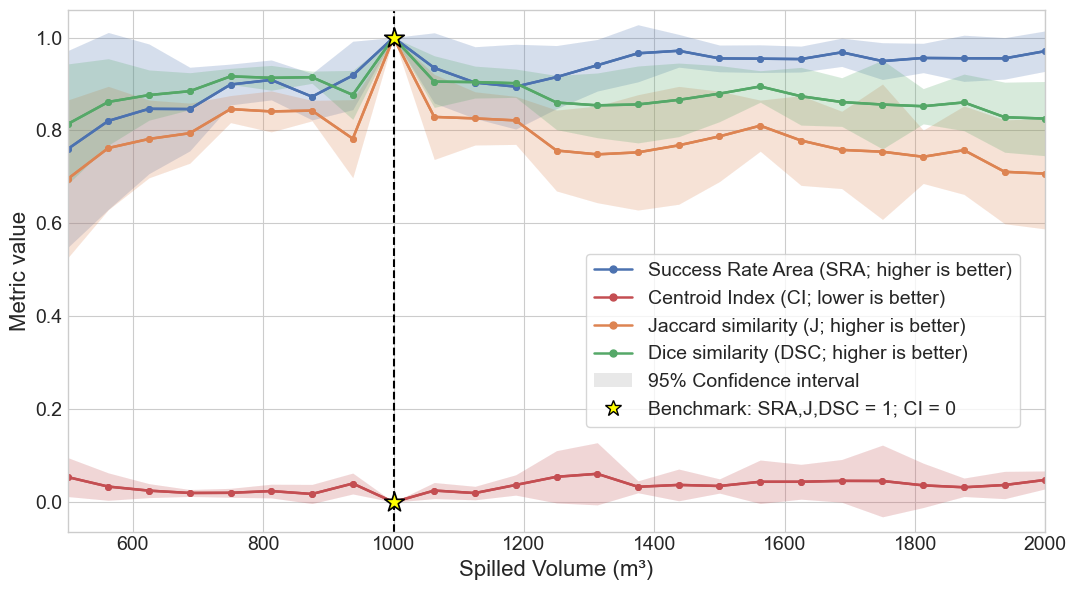

In [11]:
plot_metrics = [
    ("SRA", "Success Rate Area (SRA; higher is better)", "#4C72B0"),
    ("CI", "Centroid Index (CI; lower is better)", "#C44E52"),
    ("Jaccard", "Jaccard similarity (J; higher is better)", "#DD8452"),
    ("DICE", "Dice similarity (DSC; higher is better)", "#55A868")
]

#
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(11, 6))
x_values = metrics_summary["volume_spilled_m3"].to_numpy(dtype=float)
interval_lower_bounds = []
interval_upper_bounds = []

for metric_name, legend_label, color in plot_metrics:
    # add plotting values: mean_values and sanity check
    mean_values = metrics_summary[f"{metric_name}_mean"].to_numpy(dtype=float)
    ci_values = metrics_summary[f"{metric_name}_ci95"].to_numpy(dtype=float)
    lower = mean_values - ci_values
    upper = mean_values + ci_values
    interval_lower_bounds.append(lower)
    interval_upper_bounds.append(upper)

    # Keep an explicit gap at 1000 m³: no sensitivity observation exists there.
    for side_mask in (x_values < BENCHMARK_VOLUME_M3, x_values > BENCHMARK_VOLUME_M3):
        ax.fill_between(
            # x_values[side_mask],
            x_values,
            # lower[side_mask],
            lower,
            # upper[side_mask],
            upper,
            color=color,
            alpha=0.12,
            linewidth=0,
        )
        ax.plot(
            # x_values[side_mask],
            x_values,
            # mean_values[side_mask],
            mean_values,
            color=color,
            marker="o",
            markersize=4,
            linewidth=1.8,
            label="_nolegend_",
        )

similarity_sanity = float(
    sanity_checks[["SRA", "Jaccard", "DICE"]].to_numpy(dtype=float).mean()
)
ci_sanity = float(sanity_checks["CI"].mean())
ax.scatter(
    [BENCHMARK_VOLUME_M3, BENCHMARK_VOLUME_M3],
    [similarity_sanity, ci_sanity],
    facecolor="yellow",
    edgecolor="black",
    linewidth=1.2,
    marker="*",
    s=220,
    zorder=6,
    label="_nolegend_",
)

ax.axvline(
    x=BENCHMARK_VOLUME_M3,
    color="black",
    linestyle="--",
    linewidth=1.5,
    zorder=1,
    label="_nolegend_",
)

legend_handles = [
    Line2D([0], [0], color=color, marker="o", linewidth=1.8, markersize=5, label=label)
    for _, label, color in plot_metrics
]
legend_handles.extend([
    Patch(facecolor="gray", alpha=0.18, edgecolor="none", label="95% Confidence interval"),
    #Line2D([0], [0], color="black", linestyle="--", linewidth=1.5, label="Benchmark volume (1000 m³)"),
    Line2D(
        [0],
        [0],
        color="black",
        marker="*",
        linestyle="None",
        markersize=12,
        markerfacecolor="yellow",
        markeredgecolor="black",
        label="Benchmark: SRA,J,DSC = 1; CI = 0",
    ),
])

all_interval_bounds = np.concatenate([*interval_lower_bounds, *interval_upper_bounds])
y_min = min(0.0, ci_sanity, float(np.nanmin(all_interval_bounds)))
y_max = max(1.0, similarity_sanity, float(np.nanmax(all_interval_bounds)))
y_margin = max(0.03, 0.03 * max(y_max - y_min, 1.0))

ax.set_xlabel("Spilled Volume (m³)", fontsize=16)
ax.set_ylabel("Metric value", fontsize=16)
ax.tick_params(labelsize=14)
# ax.set_title(f"Spilled-volume sensitivity analysis with {N_REPLICATES} common-seed replicates test", fontsize=14, pad=15)
ax.set_xlim(VOLUME_MIN_M3, VOLUME_MAX_M3)
ax.set_ylim(y_min - y_margin, y_max + y_margin)
#ax.set_ylim(0, 1)
ax.legend(
    handles=legend_handles,
    # loc="best",
    bbox_to_anchor=(0.52, 0.55),
    frameon=True,
    fontsize=14,
)

fig.tight_layout()
PLOT_PATH = OUTPUT_DIR / "volume_spilled_sensitivity_common_seed_replicates.png"
fig.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
print(f"Saved plot to {PLOT_PATH}")
plt.show()